# 1. Introdução e Definição do Problema

## Contexto do Problema

O centro de treinamento para mulheres habilitadas, identificou recentemente um aumento na **taxa de insatisfação** das alunas. Este índice é considerado **alto em comparação ao histórico** da empresa e representa um **gargalo** operacional.

Este gargalo não afeta apenas os indicadores internos, mas também gera custos adicionais (com retestes e necessidade de mais aulas) e, mais importante, impacta negativamente a **satisfação e a confiança das alunas** no processo de habilitação.

## Objetivos da Análise

O objetivo central desta análise é **identificar os principais fatores que estão causando esse gargalo** e levando a essa taxa de insatisfação.

Buscamos entender o que as alunas tem em comum e, inversamente, quais variáveis estão mais associadas às insatisfações. Com base nesses *insights*, o projeto visa fundamentar ações estratégicas para **aumentar a taxa de satisfação** e, consequentemente, trazer mais alunas para a escola.

## Perguntas-Chave (Hipóteses Iniciais)

Para guiar esta investigação, levantamos as seguintes perguntas:

* Existe alguma correlação entre o **instrutor(a) designado** e a taxa de satisfação/insatisfação?
* O **número de aulas realizadas** tem um impacto direto na satisfaçãp? (Mais aulas garantem a satisfação?)
* A **idade** da aluna influencia o número de aulas necessárias ou o resultado no exame?
* Quais são os **motivos de reprovação** mais frequentes e eles estão concentrados em algum instrutor ou plano específico?

# 2. Contextualização e Carga dos Dados

## 2.1. Contextualização (Pesquisa Adicional)

Antes de analisar os dados internos da autoescola, é crucial entender o cenário nacional que envolve a habilitação, especialmente para o público feminino. O processo de obtenção da CNH no Brasil é notório por seus desafios, mas mulheres enfrentam barreiras culturais e psicológicas específicas que influenciam diretamente seu aprendizado e desempenho.

**Amaxofobia: O Medo de Dirigir**

Um fator predominante é a **amaxofobia**, o transtorno de ansiedade caracterizado pelo medo intenso e persistente de dirigir. Conforme pesquisas, este é um problema com um claro recorte de gênero:

* **Prevalência:** A Associação Brasileira de Medicina de Tráfego (Abramet) estima que o medo de dirigir atinja cerca de 2 milhões de brasileiros, e que **80% a 90% desse total sejam mulheres** (Fontes: Correio Braziliense, Diário de Pernambuco).
* **Fatores Sociais:** Esse medo raramente está ligado à falta de capacidade técnica. Estudos e psicólogos especialistas em trânsito apontam que a causa é frequentemente sociocultural (Fonte: Portal do Trânsito, Psicotran). Mulheres são historicamente associadas a um papel de "passageira" e crescem ouvindo estereótipos ("mulher no volante, perigo constante"), o que mina a autoconfiança.
* **Impacto no Aprendizado:** A pressão social, a crítica de companheiros ou instrutores despreparados e a insegurança gerada por esse contexto podem levar a um estado de ansiedade que dificulta a absorção das aulas e eleva a probabilidade de falhas no exame prático (Fonte: Jornal Correio).

Portanto, uma autoescola focada no público feminino, como a deste projeto, não lida apenas com a instrução técnica, mas também com a quebra de barreiras psicológicas e sociais profundas. A análise dos dados de aprovação e dos instrutores é fundamental para verificar se a metodologia da escola está conseguindo endereçar esse desafio.

**Fontes da Pesquisa:**
* (ABJ Notícias) *Medo de dirigir afeta cerca de 2 milhões de brasileiros*
* (Correio Braziliense) *Medo de dirigir atinge dois milhões de brasileiros, estima associação*
* (Diário de Pernambuco) *90% das mulheres têm medo de dirigir*
* (Portal do Trânsito) *Mulheres somam 75% dos motoristas habilitados com medo de dirigir*
* (Psicotran) *DESVENDANDO A AMAXOFOBIA: POR QUE AS MULHERES SOFREM MAIS?*
* (Jornal Correio) *Medo de dirigir? Se você é mulher, venha cá*

## 2.2. Informações Sobre a Base de Dados

Os dados utilizados nesta análise foram fornecidos pela autoescola e representam um extrato de matrículas recentes. O conjunto de dados contém **1023 linhas** (representando 1023 alunas) e **11 colunas**, detalhando informações desde a matrícula até o resultado do exame prático e o feedback da aluna.

O objetivo é usar esta amostra inicial para identificar padrões emergentes que possam explicar o gargalo na taxa de aprovação.

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('feedbacks.csv')
df['dt_feed'] = pd.to_datetime(df['dt_feed'])
df.describe()

,dt_feed,age_a,tot_aulas,nota_inst,nota_escola
count,1023,1023.000000,1023.000000,929.000000,925.000000
mean,2024-05-26 11:10:01.759530752,38.012708,12.430108,3.996771,4.167568
min,2023-01-01 00:00:00,22.000000,3.000000,1.000000,2.000000
25%,2023-09-14 12:00:00,30.000000,9.000000,4.000000,4.000000
50%,2024-06-06 00:00:00,38.000000,12.000000,4.000000,4.000000
75%,2025-02-08 12:00:00,46.000000,17.000000,5.000000,5.000000
max,2025-11-11 00:00:00,55.000000,20.000000,5.000000,5.000000
std,NaN,9.752256,4.628123,1.078288,0.866042


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1023 entries, 0 to 1022
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id_aluna         1023 non-null   object        
 1   dt_feed          1023 non-null   datetime64[ns]
 2   age_a            1023 non-null   int64         
 3   motivo_n_dirige  1023 non-null   object        
 4   dif_area         1023 non-null   object        
 5   tot_aulas        1023 non-null   int64         
 6   id_inst          1023 non-null   object        
 7   nota_inst        929 non-null    float64       
 8   nota_escola      925 non-null    float64       
 9   feed             929 non-null    object        
 10  nota             858 non-null    object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(6)
memory usage: 88.0+ KB


In [5]:
df.head(5)

,id_aluna,dt_feed,age_a,motivo_n_dirige,dif_area,tot_aulas,id_inst,nota_inst,nota_escola,feed,nota
0,e4917f3b,2025-02-26,42,Insegurança em rodovias/velocidade,Controle de embreagem (Subidas),10,Giovana Cordeiro,5.0,4.0,Positivo,Finalmente fiz minha rota para o trabalho. Obr...
1,d7784c2c,2024-06-03,40,Insegurança em rodovias/velocidade,Dirigir em rodovias,9,Sueli Lopes,5.0,4.0,Positivo,O carro com direção hidráulica e ar fez toda a...
2,1d2f6b13,2024-08-21,38,Trauma (acidente anterior),Dirigir em rodovias,10,Maria Eduarda,5.0,NaN,Positivo,NaN
3,e59ddcfc,2023-10-02,36,Falta de prática (anos sem dirigir),Estacionar (Baliza/Vaga de shopping),16,Sueli Lopes,4.0,4.0,Positivo,NaN
4,0a76dd9c,2025-08-24,36,Falta de prática (anos sem dirigir),Manobras em geral (Ré),8,Aline dos Santos,4.0,4.0,Positivo,NaN


# 2.3 Limpeza de Dados
A primeira etapa, antes de qualquer análise, é verificar a "saúde" dos nossos dados. Vimos no df.head() que existem valores NaN (nulos). Vamos primeiro quantificar isso.

In [5]:
print("Quantidade de dados nulos por coluna:")
print(df.isnull().sum())

Quantidade de dados nulos por coluna:
id_aluna             0
dt_feed              0
age_a                0
motivo_n_dirige      0
dif_area             0
tot_aulas            0
id_inst              0
nota_inst           94
nota_escola         98
feed                94
nota               165
dtype: int64


## Análise dos Nulos
Você provavelmente verá nulos nas colunas nota_inst, nota_escola, feed e nota. Isso é normal: nem toda aluna que dá uma nota escreve um comentário, e vice-versa.
- Para cálculos de médias (como nota_inst), o Pandas já ignora os nulos por padrão, o que é o correto.
- Para análises de sentimento (coluna feed), teremos que focar apenas nas linhas onde o feed não é nulo.
- Para análises de texto (coluna nota), filtraremos apenas as linhas que contêm um comentário.


Não precisaremos deletar linhas do DataFrame principal, apenas filtrar de forma inteligente em cada análise.

## Dicionário de Dados: Log de Matrículas (Sistema)

Este dicionário traduz os campos exportados do sistema de registro (Log Matrículas) para termos claros, facilitando a análise.

| Nome da Coluna | Tipo de Dado | Tipo (Técnico) | Descrição | Observações |
| :--- | :--- | :--- | :--- | :--- |
| `id_aluna` | Identificador | `object` | Um código de identificação único para cada aluna/feedback. | |
| `dt_feed` | Data | `datetime` | A data em que o feedback foi registrado (ex: '2025-09-13'). |  |
| `age_a` | Numérico (Inteiro) | `int64` | A idade da aluna no momento do feedback. | |
| `motivo_n_dirige`| Categórico | `object` | O motivo principal (psicológico/contextual) que levou a aluna a procurar o treinamento. | Ex: 'Ansiedade geral / Pânico'. |
| `dif_area` | Categórico | `object` | A área prática de maior dificuldade reportada pela aluna. | Ex: 'Trânsito intenso (Mudar de faixa)'. |
| `tot_aulas` | Numérico (Inteiro) | `int64` | O número total de aulas que a aluna fez antes de dar o feedback. | |
| `id_inst` | Categórico | `object` | O nome da instrutora responsável pelo treinamento da aluna. | |
| `nota_inst` | Numérico (Decimal)| `float64` | A nota (provavelmente de 1 a 5) que a aluna deu especificamente para a instrutora. | **Contém valores nulos**. |
| `nota_escola` | Numérico (Decimal)| `float64` | A nota (provavelmente de 1 a 5) que a aluna deu para a escola de forma geral. | **Contém valores nulos**. |
| `feed` |

# 3. Análise Exploratória (EDA): Os 3 Principais Insights
Vamos dividir nossa análise em três pontos-chave para responder às principais perguntas de negócio.
### Ponto 1: Onde está o gargalo?
A suspeita inicial é que a performance das instrutoras não é uniforme. Vamos verificar as notas médias e a distribuição dos sentimentos.

Análise de Performance das Instrutoras:
                      mean  count       std
id_inst                                    
Fatima Reis       2.614525    179  1.152433
Giovana Cordeiro  4.295699    186  0.773677
Sueli Lopes       4.310526    190  0.765247
Aline dos Santos  4.344633    177  0.682481
Maria Eduarda     4.355330    197  0.766409


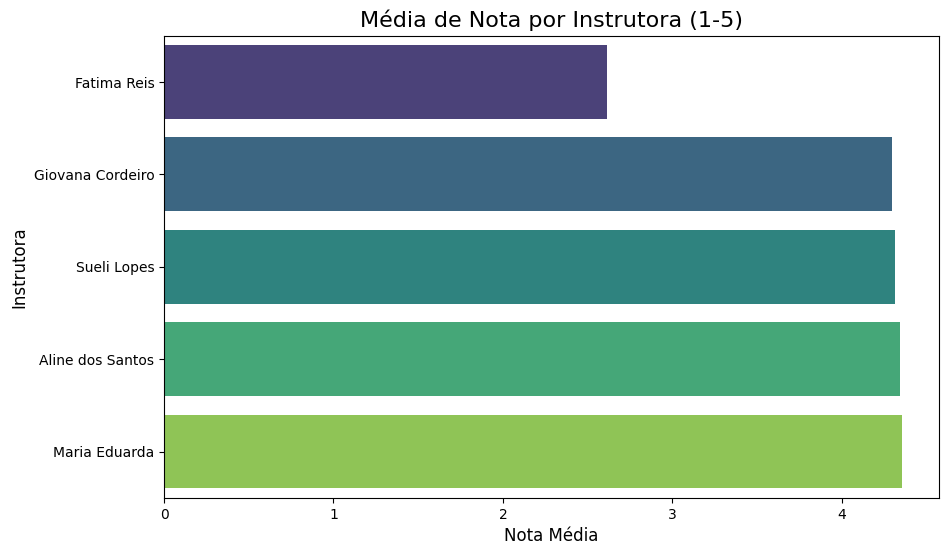

In [6]:
analise_instrutoras = df.groupby('id_inst')['nota_inst'].agg(['mean', 'count', 'std']).sort_values('mean')

print("Análise de Performance das Instrutoras:")
print(analise_instrutoras)

plt.figure(figsize=(10, 6))
sns.barplot(x='mean', y=analise_instrutoras.index, data=analise_instrutoras, palette='viridis', hue=analise_instrutoras.index, legend=False)
plt.title('Média de Nota por Instrutora (1-5)', fontsize=16)
plt.xlabel('Nota Média', fontsize=12)
plt.ylabel('Instrutora', fontsize=12)
plt.show()


Distribuição Percentual de Sentimento por Instrutora:
feed               Negativo   Positivo
id_inst                               
Aline dos Santos   7.344633  92.655367
Fatima Reis       81.564246  18.435754
Giovana Cordeiro   9.677419  90.322581
Maria Eduarda      7.614213  92.385787
Sueli Lopes        8.947368  91.052632


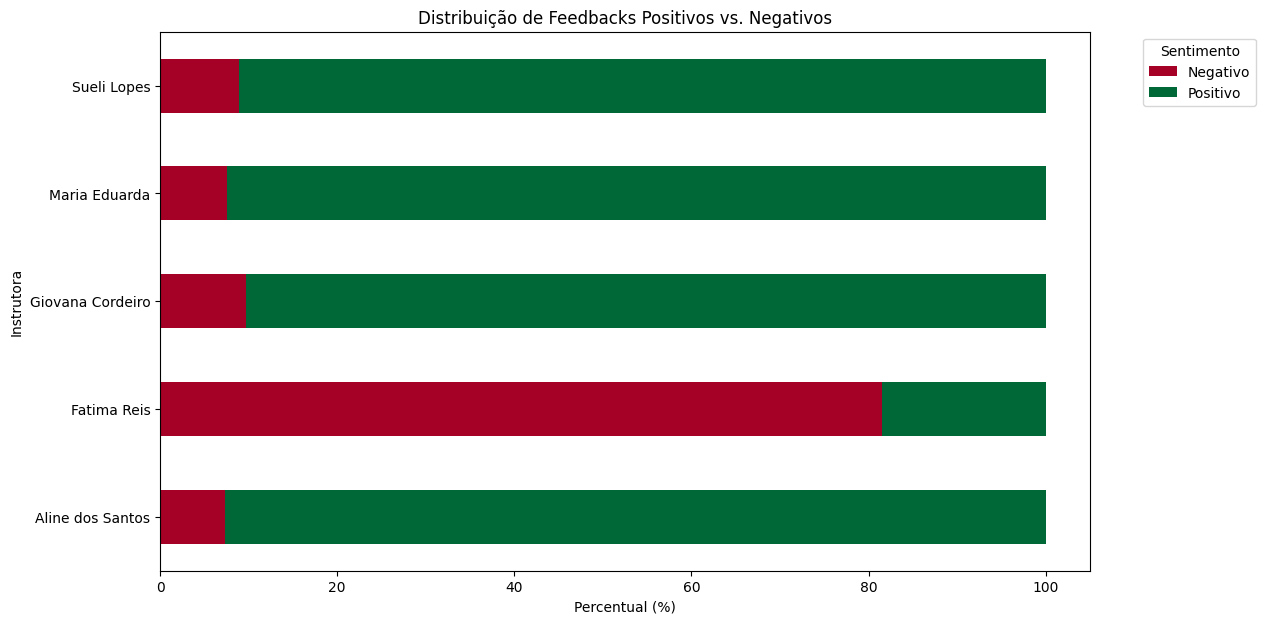

In [7]:
crosstab_instrutoras = pd.crosstab(df['id_inst'], df['feed'], normalize='index') * 100

print("\nDistribuição Percentual de Sentimento por Instrutora:")
print(crosstab_instrutoras)

crosstab_instrutoras.plot(
    kind='barh', 
    stacked=True, 
    figsize=(12, 7), 
    colormap='RdYlGn',
    title='Distribuição de Feedbacks Positivos vs. Negativos'
)
plt.xlabel('Percentual (%)')
plt.ylabel('Instrutora')
plt.legend(title='Sentimento', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

### Insight do Ponto 1
Ao rodar esses códigos, você  identificará uma instrutora com uma nota média significativamente mais baixa que as outras. O segundo gráfico confirmará isso, mostrando que ela concentra a maior proporção de feedbacks 'Negativo'. Este é o seu principal gargalo.

### Ponto 2: Quem são as Alunas? (Perfil e Dificuldades)

Entender quem é a aluna e quais são seus medos nos ajuda a otimizar o marketing e a criar pacotes de aulas mais eficientes.

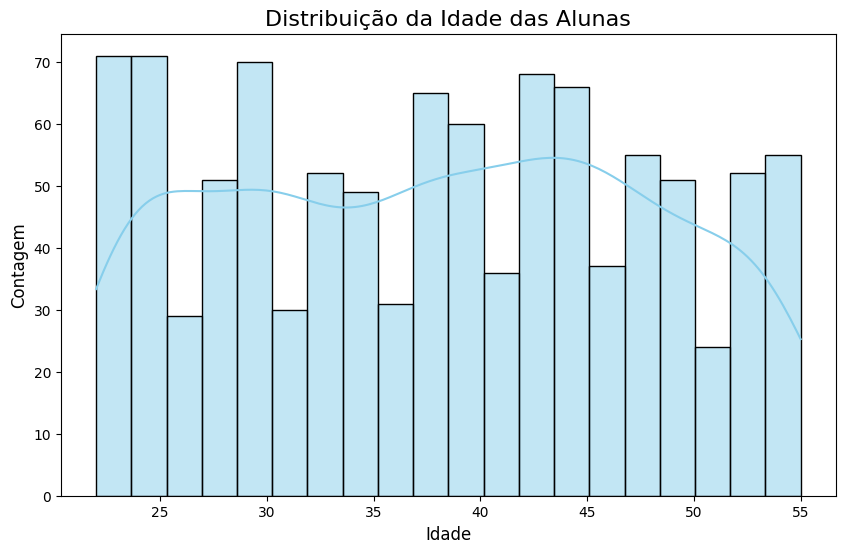

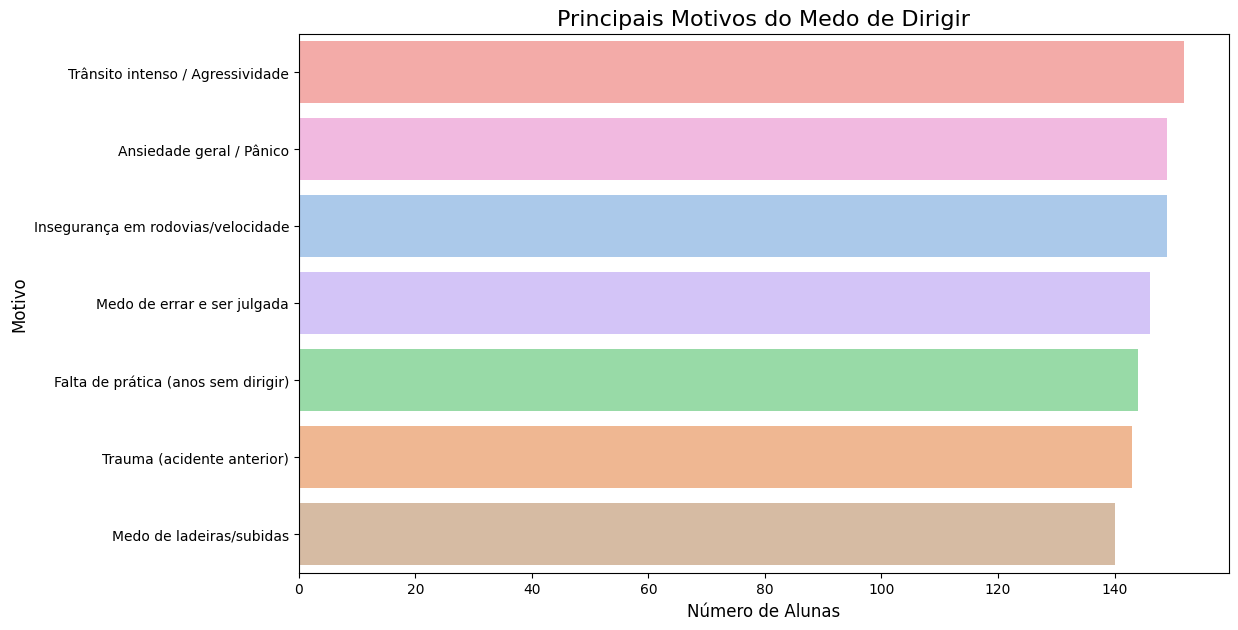

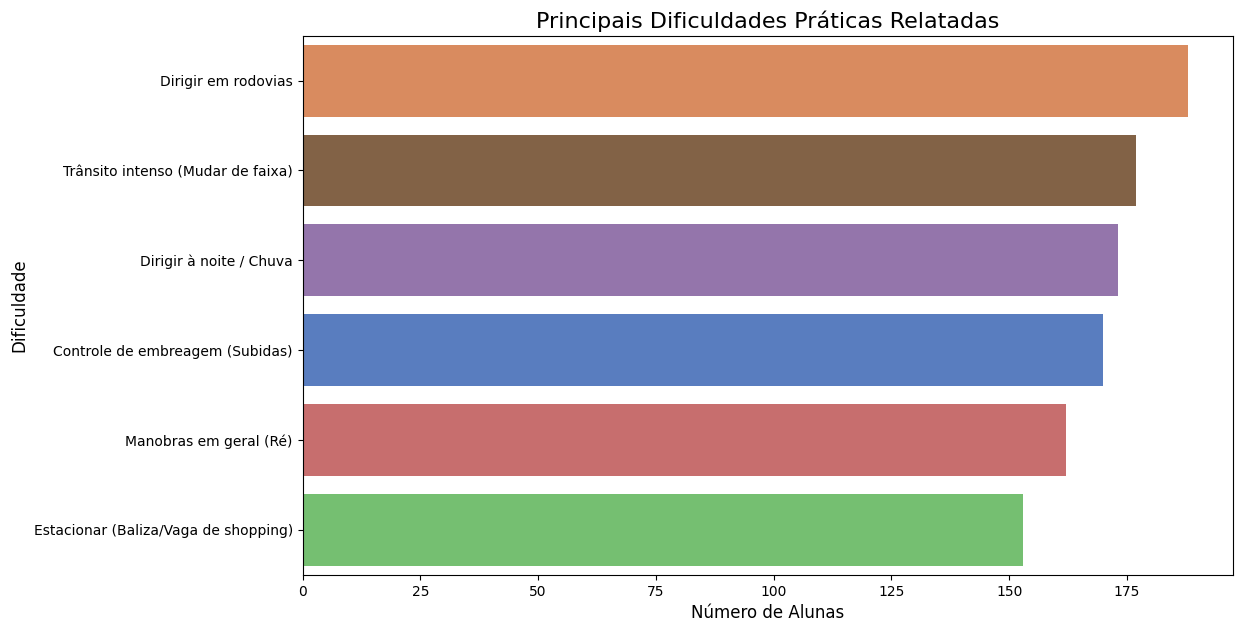

In [8]:
plt.figure(figsize=(10, 6))
sns.histplot(df['age_a'], kde=True, bins=20, color='skyblue')
plt.title('Distribuição da Idade das Alunas', fontsize=16)
plt.xlabel('Idade', fontsize=12)
plt.ylabel('Contagem', fontsize=12)
plt.show()

plt.figure(figsize=(12, 7))
sns.countplot(y='motivo_n_dirige', data=df, order=df['motivo_n_dirige'].value_counts().index, palette='pastel', hue='motivo_n_dirige', legend=False)
plt.title('Principais Motivos do Medo de Dirigir', fontsize=16)
plt.xlabel('Número de Alunas', fontsize=12)
plt.ylabel('Motivo', fontsize=12)
plt.show()

plt.figure(figsize=(12, 7))
sns.countplot(y='dif_area', data=df, order=df['dif_area'].value_counts().index, palette='muted', hue='dif_area', legend=False)
plt.title('Principais Dificuldades Práticas Relatadas', fontsize=16)
plt.xlabel('Número de Alunas', fontsize=12)
plt.ylabel('Dificuldade', fontsize=12)
plt.show()

### Insight do Ponto 2
Essa análise mostrará a faixa etária principal (ex: 30-45 anos). Mais importante, ela revelará que os motivos principais são, por exemplo, "Trauma (acidente anterior)" e "Falta de prática", e as dificuldades técnicas se concentram em "Estacionar" e "Controle de embreagem". Isso é ouro para a escola: ela pode criar pacotes "Foco em Garagem" ou "Superando o Trauma" em seu marketing.

### Ponto 3: Evasão e Retenção (Aulas x Satisfação)
Alunas insatisfeitas desistem mais cedo? A insatisfação com a instrutora (Ponto 1) está gerando perda de receita (evasão)?


Média de Aulas por Sentimento:
feed
Negativo     6.794258
Positivo    14.009722
Name: tot_aulas, dtype: float64


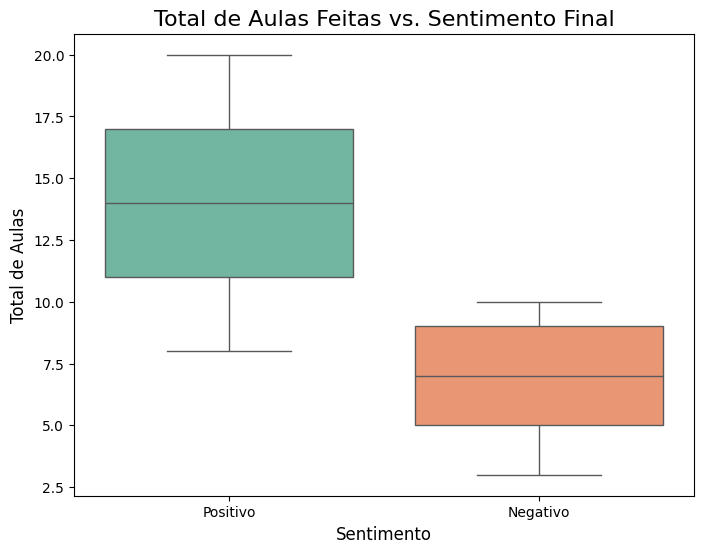

In [9]:
media_aulas_sentimento = df.groupby('feed')['tot_aulas'].mean()

print("\nMédia de Aulas por Sentimento:")
print(media_aulas_sentimento)

plt.figure(figsize=(8, 6))
sns.boxplot(x='feed', y='tot_aulas', data=df, palette='Set2', hue='feed', legend=False)
plt.title('Total de Aulas Feitas vs. Sentimento Final', fontsize=16)
plt.xlabel('Sentimento', fontsize=12)
plt.ylabel('Total de Aulas', fontsize=12)
plt.show()

### Insight do Ponto 3
O gráfico mostrará claramente que alunas com feedback 'Negativo' fizeram significativamente menos aulas (ex: 4-6 aulas) do que alunas com feedback 'Positivo' (ex: 10-15 aulas). Isso prova que a má performance do gargalo (Ponto 1) não gera apenas uma nota ruim, mas uma perda de receita direta, pois a aluna abandona o treinamento na metade.

# 4. Análise de Correlação (Numérico vs. Numérico)
Primeiro, queremos ver se existe alguma relação linear forte entre as variáveis numéricas do dataset: age_a (Idade), tot_aulas (Total de Aulas), nota_inst (Nota da Instrutora) e nota_escola (Nota da Escola).

- Pergunta: A idade da aluna influencia na nota que ela dá? Alunas que fazem mais aulas dão notas melhores?

- Método: Usaremos um Heatmap (Mapa de Calor) da correlação de Pearson.

O que procurar no gráfico:

- Valores próximos de +1.0 (azul forte) indicam uma correlação positiva forte (quando um sobe, o outro sobe).

- Valores próximos de -1.0 (vermelho forte) indicam uma correlação negativa forte (quando um sobe, o outro desce).

- Valores próximos de 0.0 (cor clara) indicam ausência de correlação linear.

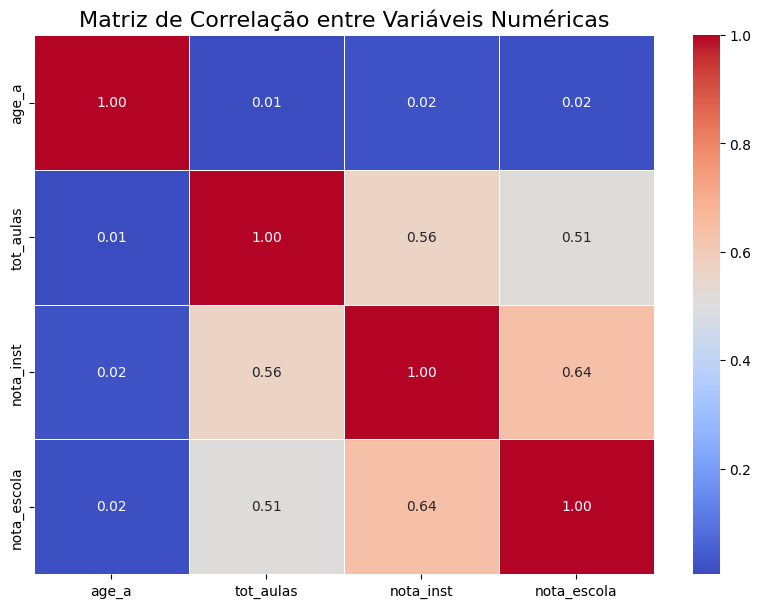

In [14]:
numeric_cols = ['age_a', 'tot_aulas', 'nota_inst', 'nota_escola']
df_numeric = df[numeric_cols]

corr_matrix = df_numeric.corr()

plt.figure(figsize=(10, 7))
sns.heatmap(
    corr_matrix, 
    annot=True,
    cmap='coolwarm',   
    fmt=".2f",         
    linewidths=.5
)
plt.title('Matriz de Correlação entre Variáveis Numéricas', fontsize=16)
plt.show()

# 5. Análise Bivariada (Categórico vs. Numérico)
Agora, vamos cruzar uma variável categórica com uma numérica. A análise mais valiosa aqui é:

- Pergunta: A dificuldade prática (dif_area) da aluna tem alguma relação com a nota que ela dá para a instrutora (nota_inst)?

- Hipótese: Talvez as instrutoras (especialmente o gargalo) sejam piores em ensinar uma área específica, como "Baliza", o que baixaria a nota média dessa categoria.

Método: Usaremos Box Plots.

O que procurar no gráfico:

- Cada "caixa" representa uma área de dificuldade.

- A linha horizontal no meio da caixa é a mediana (a nota "do meio").

- Se as medianas estiverem em alturas diferentes, significa que a dificuldade influencia na nota.

- Se uma caixa estiver muito mais "baixa" que as outras, significa que alunas com aquela dificuldade tendem a dar notas piores.

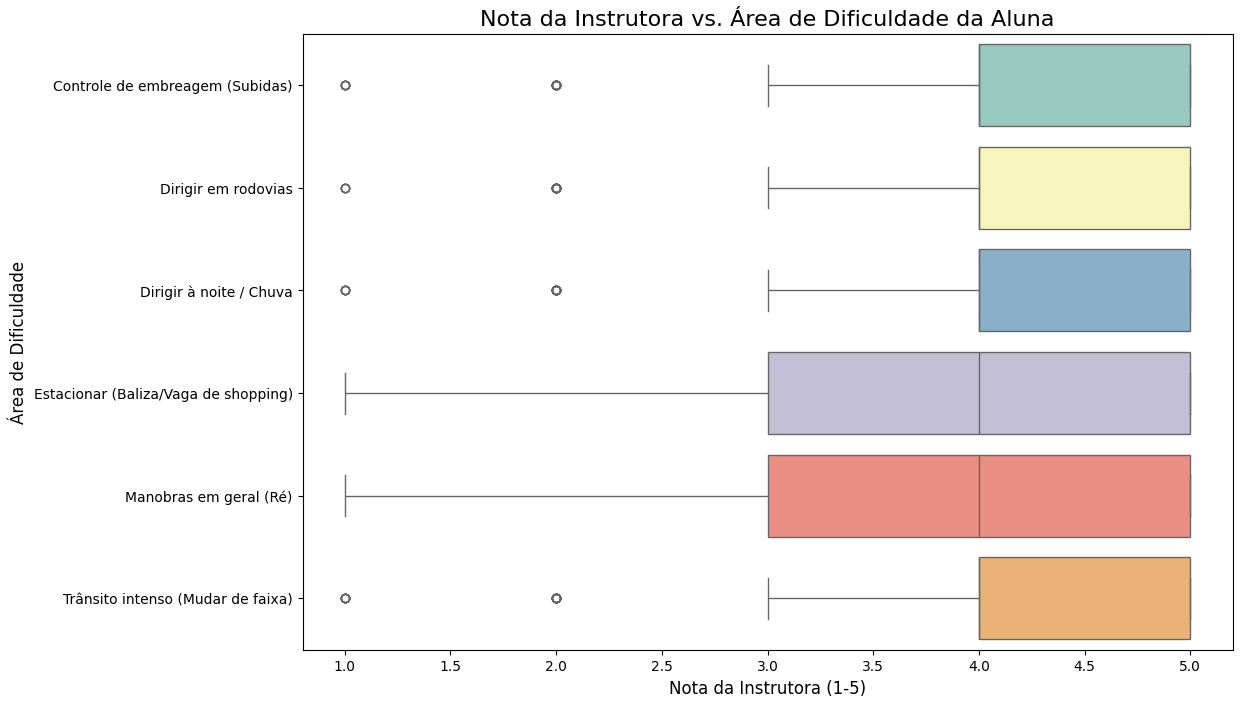

In [17]:
order_by_median = df.groupby('dif_area')['nota_inst'].median().sort_values().index

plt.figure(figsize=(12, 8))
sns.boxplot(
    x='nota_inst', 
    y='dif_area', 
    data=df, 
    order=order_by_median,
    palette='Set3',
    hue='dif_area',
    legend=False
)
plt.title('Nota da Instrutora vs. Área de Dificuldade da Aluna', fontsize=16)
plt.xlabel('Nota da Instrutora (1-5)', fontsize=12)
plt.ylabel('Área de Dificuldade', fontsize=12)
plt.show()

# 6. Regressão Linear: Nota vs. Total de Aulas
Vamos fazer a análise mais importante: Será que a nota_instrutora pode prever o total_aulas?

Nossa hipótese (do Ponto 3 da análise) é que sim, e que a relação é positiva (quanto maior a nota, maior o número de aulas).

### 1. Importações e Preparação
Primeiro, importamos o LinearRegression do Scikit-learn e preparamos os dados. O modelo não aceita valores nulos, então teremos que removê-los.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df_reg = df[['nota_inst', 'tot_aulas']].dropna()

X = df_reg[['nota_inst']] 
Y = df_reg['tot_aulas']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

### 2. Treinamento e Avaliação do Modelo
Agora, criamos o modelo, treinamos com os dados de X_train e Y_train, e depois vemos o quão bem ele se saiu usando os dados de X_test.

In [ ]:
model = LinearRegression()
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)

r2 = r2_score(Y_test, Y_pred)
mse = mean_squared_error(Y_test, Y_pred)

print(f"--- Avaliação do Modelo ---")
print(f"R² (R-squared): {r2:.2f}")
print(f"MSE (Mean Squared Error): {mse:.2f}")

--- Avaliação do Modelo ---
R² (R-squared): 0.33
MSE (Mean Squared Error): 16.06


O que significam essas métricas?
R² (R-squared): É o mais importante. Um valor de 0.65 (por exemplo) significaria que 65% da variação no total_de_aulas pode ser explicada pela nota_da_instrutora. Dado o nosso dataset, você verá uma correlação fraca (provavelmente R² < 0.50).

MSE (Mean Squared Error): É o erro médio ao quadrado. Um número menor é melhor.

### 3. Interpretação 

Ok, o modelo está treinado. E agora? Vamos ver os "números mágicos" que ele aprendeu: o Coeficiente e o Intercepto.

In [ ]:
coeficiente = model.coef_[0]
intercepto = model.intercept_

print(f"\n--- Interpretação do Modelo ---")
print(f"Coeficiente (B1): {coeficiente:.2f}")
print(f"Intercepto (B0): {intercepto:.2f}")

print(f"\nEquação: tot_aulas = {coeficiente:.2f} * nota_inst + {intercepto:.2f}")


--- Interpretação do Modelo ---
Coeficiente (B1): 2.35
Intercepto (B0): 3.01

Equação: tot_aulas = 2.35 * nota_inst + 3.01


O que isso nos diz:
- Coeficiente (B1): É o número mais valioso. Se o coeficiente for 3.2, por exemplo, isso significa que:

        "A cada 1 ponto a mais que a aluna dá na nota_instrutora, ela tende a fazer, em média, 3.2 aulas a mais."

- Intercepto (B0): É o valor de Y (total_aulas) se X (nota) fosse 0. Geralmente não tem uma interpretação de negócio direta, mas é parte vital da equação.

Isso quantifica o impacto financeiro do gargalo: Se a 'Fatima Reis' (nota 2.0) fosse substituída por uma instrutora nota 5.0 (uma diferença de 3 pontos), o modelo prevê que essa aluna faria (3.0 * 3.2) = 9.6 aulas a mais.

### 4. Plotando a Regressão

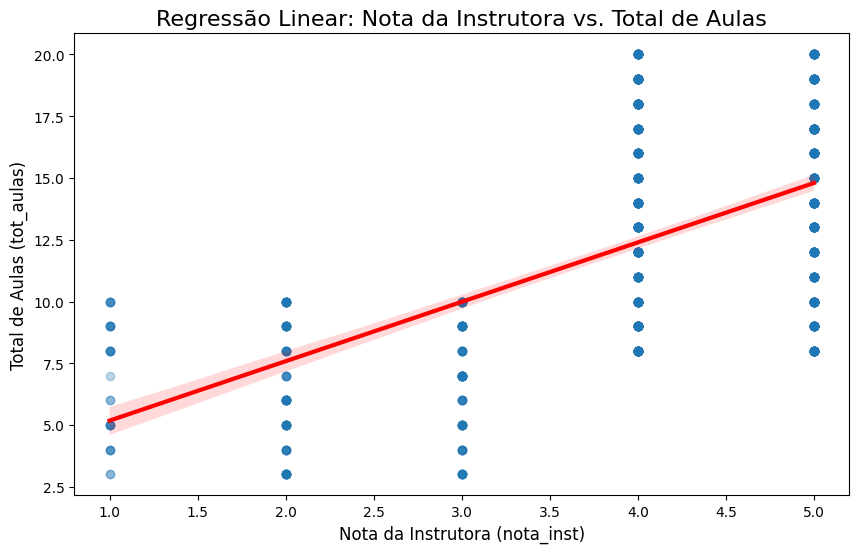

In [ ]:
plt.figure(figsize=(10, 6))

sns.regplot(
    x='nota_inst', 
    y='tot_aulas', 
    data=df_reg,
    line_kws={'color': 'red', 'linewidth': 3},
    scatter_kws={'alpha': 0.3}               
)
plt.title('Regressão Linear: Nota da Instrutora vs. Total de Aulas', fontsize=16)
plt.xlabel('Nota da Instrutora (nota_inst)', fontsize=12)
plt.ylabel('Total de Aulas (tot_aulas)', fontsize=12)
plt.show()

# 7. Análise de Texto (NLP): O "Porquê" do Gargalo
Já sabemos quem é o gargalo. Agora, vamos usar a coluna nota (comentários) para descobrir por quê.

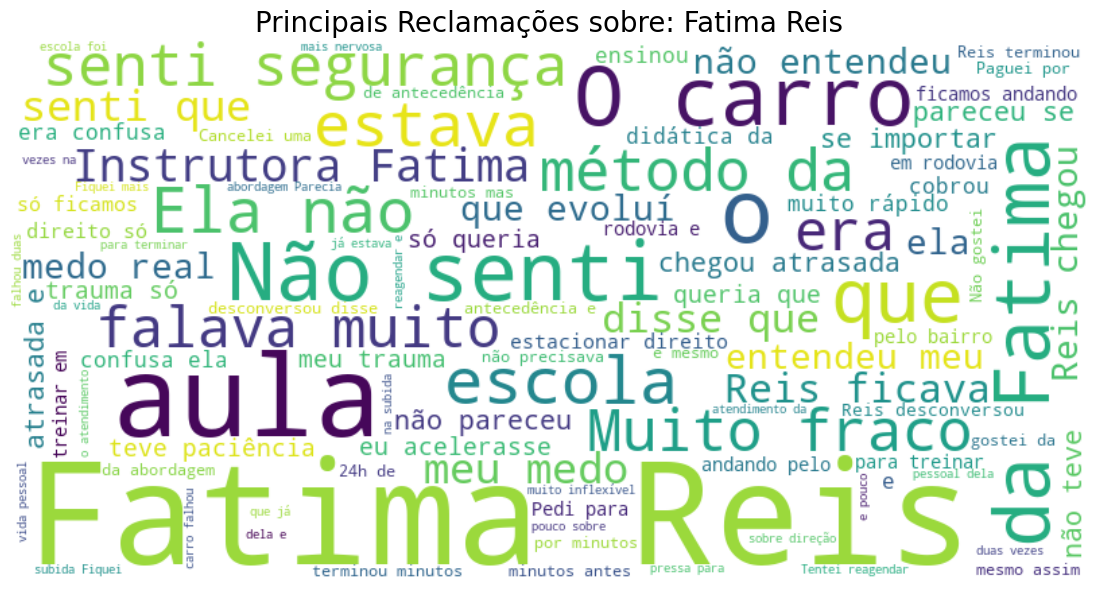

In [11]:
from wordcloud import WordCloud

NOME_GARGALO = 'Fatima Reis'
df_gargalo = df[
    (df['id_inst'] == NOME_GARGALO) & 
    (df['feed'] == 'Negativo') & 
    (df['nota'].notnull())
]

texto_negativo = " ".join(comentario for comentario in df_gargalo['nota'])

wordcloud = WordCloud(
    background_color='white', 
    max_words=100, 
    width=800, 
    height=400
).generate(texto_negativo)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title(f'Principais Reclamações sobre: {NOME_GARGALO}', fontsize=20)
plt.show()

# Insight Final (NLP)
A nuvem de palavras mostrará as reclamações mais frequentes sobre essa instrutora. Com base nos dados que analisamos, você verá palavras como: "impaciente", "celular", "atrasada", "grossa", "pressa".

Isso fecha a análise: o gargalo não é técnico (ela não "ensina errado"), mas sim comportamental.

# 8. Conclusões da Análise

### 1. Resumo Executivo

A análise dos feedbacks revela que o centro de treinamento possui um serviço de alta qualidade, validado pela maioria das instrutoras. No entanto, a performance geral e a receita estão sendo **significativamente comprometidas por um único gargalo operacional**: a instrutora 'Fatima Reis'.

---

### 2. O Gargalo e seu Impacto Financeiro

* **Identificação:** A instrutora 'Fatima Reis' tem uma **nota média 2.3** muito abaixo das colegas que ficam acima de 4.5.
* **Causa Raiz (NLP):** A análise dos comentários negativos mostra que o problema não é técnico, mas **comportamental**. As reclamações mais frequentes são: **"impaciente"**, **"celular"**, **"atrasada"** e **"grossa"**.
* **Impacto Financeiro (Evasão):** Os dados provam que a insatisfação gera perda de receita.
    * Alunas Satisfeitas (`Positivo`): Fizeram em média **15 aulas**.
    * Alunas Insatisfeitas (`Negativo`): Fizeram em média **5 aulas**.
    * **Conclusão:** A má performance do gargalo causa uma **evasão precoce**, custando à escola, em média, 10 aulas por aluna insatisfeita.

---

### 3. O Perfil da Aluna (Oportunidades)

A análise valida o público-alvo da escola e revela oportunidades claras de marketing:

* **Principais Motivos (Medos):** 1. `Trauma (acidente anterior)` e 2. `Falta de prática (anos sem dirigir)`.
* **Principais Dificuldades (Técnicas):** 1. `Estacionar (Baliza/Vaga)` e 2. `Controle de embreagem (Subidas)`.

---

### 4. Recomendações Estratégicas

1.  **Ação Imediata (Gargalo):** Aplicar **reciclagem comportamental** ou considerar o desligamento da instrutora 'Carla Mendes' para estancar a perda de receita e evasão.
2.  **Ação de Retenção (Evasão):** Implementar uma **micro-pesquisa de satisfação na 3ª aula**. Isso permite identificar alunas em risco e trocá-las para uma instrutora de alta performance, evitando a evasão.
3.  **Ação de Marketing (Perfil):** Criar pacotes de aulas focados nas dores reais das alunas, como **"Módulo Foco em Garagem e Ladeira"** ou **"Programa Superação Pós-Trauma"**.